In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import panel as pn
!pip install hvplot
import hvplot.pandas
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
movies_df = pd.read_csv("movies.csv")
metadata_df = pd.read_csv("movies_metadata.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving movies.csv to movies (2).csv
Saving movies_metadata.csv to movies_metadata (1).csv
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 4.6 MB/s eta 0:00:00


/tmp/ipykernel_15044/2755942822.py:31: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv("movies_metadata.csv")


In [ ]:
# Convert id columns to numeric
movies_df["id"] = pd.to_numeric(movies_df["id"], errors="coerce")
metadata_df["id"] = pd.to_numeric(metadata_df["id"], errors="coerce")

# Remove rows with missing ids or duplicates
movies_df = movies_df.dropna(subset=["id"]).drop_duplicates(subset="id")
metadata_df = metadata_df.dropna(subset=["id"]).drop_duplicates(subset="id")

# Merge the two datasets on id
df = movies_df.merge(metadata_df, on="id", how="left", suffixes=("_movies", "_meta"))

# Safe parser for genre column
def safe_parse(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []
# Convert important columns to numeric
numeric_cols = [
    "budget_movies",
    "revenue_movies",
    "popularity_movies",
    "vote_average_movies",
    "vote_count_movies",
    "runtime_movies"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create year column
df["year"] = pd.to_datetime(df["release_date_movies"], errors="coerce").dt.year

# Extract genre names and main genre
df["genre_names"] = df["genres_meta"].apply(
    lambda x: [g["name"] for g in safe_parse(x)] if isinstance(safe_parse(x), list) else []
)
df["main_genre"] = df["genre_names"].apply(lambda x: x[0] if len(x) > 0 else "Unknown")

# Create profit, return on investment, and success columns
df["profit"] = df["revenue_movies"] - df["budget_movies"]
df["roi"] = df["profit"] / df["budget_movies"].replace(0, np.nan)
df["success"] = (df["profit"] > 0).astype(int)
genre_profit = analysis_df.groupby("main_genre")["profit"].mean()
# Keep rows needed for analysis graphs
analysis_df = df.dropna(subset=numeric_cols + ["profit", "success"]).copy()

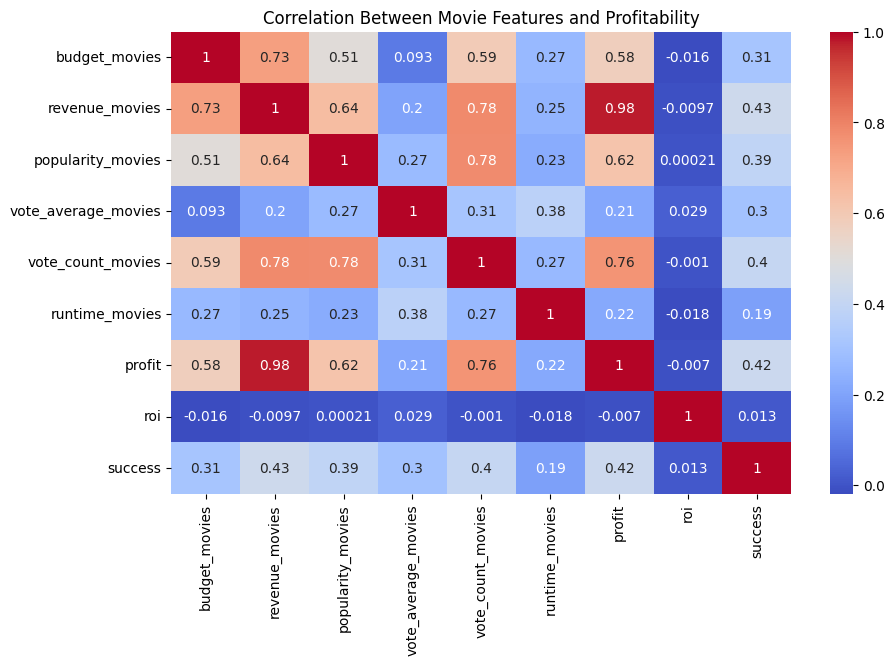

In [ ]:
# Which movie attributes have the strongest influence on profitability?
plt.figure(figsize=(10, 6))
sns.heatmap(
    analysis_df[[
        "budget_movies",
        "revenue_movies",
        "popularity_movies",
        "vote_average_movies",
        "vote_count_movies",
        "runtime_movies",
        "profit",
        "roi",
        "success"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Between Movie Features and Profitability")
plt.show()


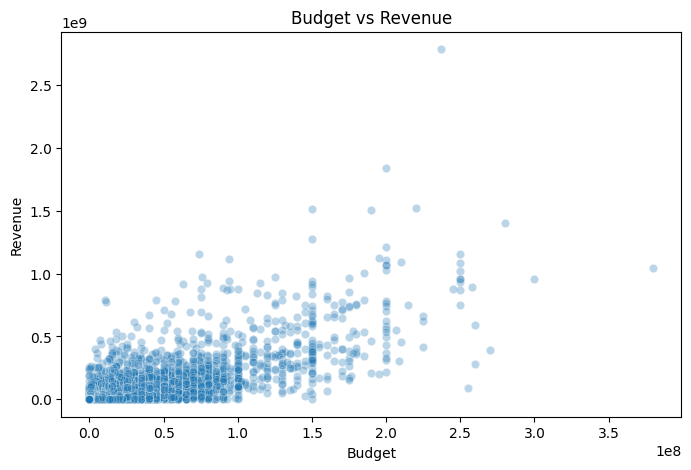

In [ ]:
# How strongly does production budget influence box office revenue?
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=analysis_df,
    x="budget_movies",
    y="revenue_movies",
    alpha=0.3
)
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()


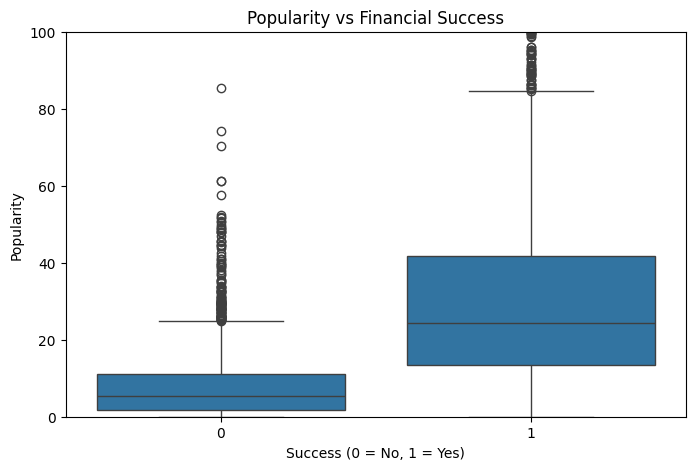

In [ ]:
# Does movie popularity correlate with financial success?
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=analysis_df,
    x="success",
    y="popularity_movies"
)
plt.ylim(0,100)
plt.title("Popularity vs Financial Success")
plt.xlabel("Success (0 = No, 1 = Yes)")
plt.ylabel("Popularity")
plt.show()

In [ ]:
## Are certain genres more likely to produce profitable films than others?
fig = px.bar(
    genre_profit.reset_index().sort_values("profit", ascending=False),
    x="main_genre",
    y="profit",
    title="Average Profit by Main Genre",
    labels={"main_genre": "Genre", "profit": "Average Profit"},
    hover_data=["profit"]
)

fig.show()

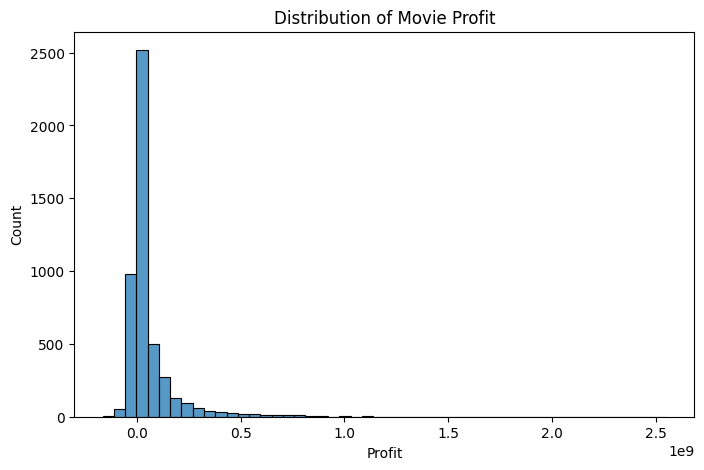

In [ ]:
# What does the distribution of movie profit look like?
plt.figure(figsize=(8, 5))
sns.histplot(analysis_df["profit"], bins=50)
plt.title("Distribution of Movie Profit")
plt.xlabel("Profit")
plt.ylabel("Count")
plt.show()


In [ ]:

pn.extension()

# create Widget panel
genre_select = pn.widgets.Select(
    name="Select Genre",
    options=sorted(analysis_df["main_genre"].dropna().unique().tolist())
)

# function to display the plot
def show_plot(genre):
    temp = analysis_df[analysis_df["main_genre"] == genre]

    return temp.hvplot.scatter(
        x="budget_movies",
        y="revenue_movies",
        size="popularity_movies",
        hover_cols=["title_movies", "profit"],
        alpha=0.6,
        height=450,
        width=700,
        title=f"Budget vs Revenue for {genre} Movies",
        xlabel="Budget",
        ylabel="Revenue"
    )
## bind the interative plot
interactive_plot = pn.bind(show_plot, genre_select)

# Display graph
pn.Column(
    "## Interactive Budget vs Revenue by Genre of the Movie",
    genre_select,
    interactive_plot
)

/tmp/ipykernel_15044/1758472931.py:1: UserWarning:

Using Panel interactively in Colab notebooks requires the jupyter_bokeh package to be installed. Install it with:

    !pip install jupyter_bokeh

and try again.



Column
    [0] Markdown(str)
    [1] Select(options=['Action', 'Adventure', ...], value='Action')
    [2] ParamFunction(function, _pane=HoloViews, defer_load=False)

/usr/local/lib/python3.12/dist-packages/panel/viewable.py:495: BokehUserWarning:

reference already known '7d9fa03c-f5d5-4d4e-9154-696ab960ec3d'



In [ ]:
feature_cols = [
    "budget_movies",
    "popularity_movies",
    "vote_average_movies",
    "vote_count_movies",
    "runtime_movies"
]

ml_df = df[feature_cols + ["success"]].copy()
ml_df = ml_df.dropna()

X = ml_df[feature_cols]
y = ml_df["success"]


In [ ]:
# Create training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))


Training set shape: (3840, 5)
Test set shape: (961, 5)

Training set class distribution:
success
1    0.538542
0    0.461458
Name: proportion, dtype: float64

Test set class distribution:
success
1    0.537981
0    0.462019
Name: proportion, dtype: float64


In [ ]:
## Logistic regression
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_prediction = log_model.predict(X_test_scaled)

log_scores = cross_val_score(log_model, X_train_scaled, y_train, cv=5)

print("\nLogistic Regression Cross-Validation Accuracy:", log_scores.mean())
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, log_prediction))


Logistic Regression Cross-Validation Accuracy: 0.7833333333333333
Logistic Regression Test Accuracy: 0.7741935483870968


In [ ]:
## decision tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_imputed, y_train)

dt_prediction = dt_model.predict(X_test_imputed)

dt_scores = cross_val_score(dt_model, X_train_imputed, y_train, cv=5)

print("\nDecision Tree Cross-Validation Accuracy:", dt_scores.mean())
print("Decision Tree Test Accuracy:", accuracy_score(y_test, dt_prediction))


Decision Tree Cross-Validation Accuracy: 0.7205729166666667
Decision Tree Test Accuracy: 0.7304890738813735


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_imputed, y_train)

rf_prediction = rf_model.predict(X_test_imputed)

feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
               Feature  Importance
3    vote_count_movies    0.394782
1    popularity_movies    0.283185
0        budget_movies    0.165103
2  vote_average_movies    0.080943
4       runtime_movies    0.075987


In [ ]:
rf_scores = cross_val_score(rf_model, X_train_imputed, y_train, cv=5)

print("\nRandom Forest Cross-Validation Accuracy:", rf_scores.mean())
print("Random Forest Test Accuracy:", accuracy_score(y_test, rf_prediction))



Random Forest Cross-Validation Accuracy: 0.7906250000000001
Random Forest Test Accuracy: 0.7845993756503642


In [ ]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "CV Accuracy": [log_scores.mean(), dt_scores.mean(), rf_scores.mean()],
    "Test Accuracy": [
        accuracy_score(y_test, log_prediction),
        accuracy_score(y_test, dt_prediction),
        accuracy_score(y_test, rf_prediction)
    ]
})
print("\nModel Comparison:")
print(results_df)




Model Comparison:
                 Model  CV Accuracy  Test Accuracy
0  Logistic Regression     0.783333       0.774194
1        Decision Tree     0.720573       0.730489
2        Random Forest     0.790625       0.784599


In [ ]:
best_model_name = results_df.sort_values(by="CV Accuracy", ascending=False).iloc[0]["Model"]
print("\nBest model based on cross-validation accuracy:", best_model_name)

if best_model_name == "Logistic Regression":
    best_pred = log_prediction
elif best_model_name == "Decision Tree":
    best_pred = dt_prediction
else:
    best_pred = rf_prediction



Best model based on cross-validation accuracy: Random Forest


In [ ]:
print("\nTest Set Evaluation for Best Model")
print("Accuracy:", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall:", recall_score(y_test, best_pred))
print("F1 Score:", f1_score(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))


Test Set Evaluation for Best Model
Accuracy: 0.7845993756503642
Precision: 0.8075396825396826
Recall: 0.7872340425531915
F1 Score: 0.7972575905974535

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       444
           1       0.81      0.79      0.80       517

    accuracy                           0.78       961
   macro avg       0.78      0.78      0.78       961
weighted avg       0.79      0.78      0.78       961



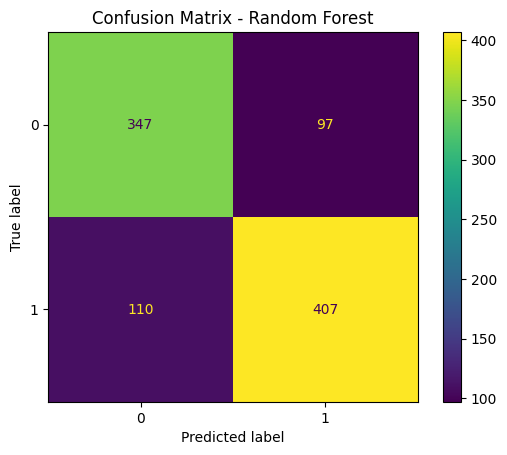

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()